#### LSTM

- RNN 구조에서 발생하는 문제를 해결하기 위해 구조를 변경한 모델
- 기존 RNN은 학습 횟수가 증가하면 과거의 기억을 잃는다.
    - 반복 학습을 하면서 가중치의 변화량이 0에 가까워진다.
    - 손실 함수 → tanh → 반복적으로 -1 ~ 1의 가중치 변화량이 곱해지면서 0에 수렴
    
- LSTM 모델은 반복 학습을 하면서 과거의 기억 중 장기 기억과 단기 기억으로 나눠주는 역할
    - 반복 학습을 하면서 tanh() 중복적으로 실행하면서 기울기는 0에 가까워짐
    - 장기 기억에 대해서는 tanh() 실행하지 않음 → 가중치의 변화 유지
    - cell 공간에 장기 기억 정보 전달
    - gate로 정보를 선택적으로 보관, 삭제, 출력

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [99]:
# 하나의 함수화
# 매개변수로 사용할 데이터들은 어떤 것이 있을까?

# 파일의 경로를 지정하는 변수 (read_csv)
file_path = '../csv/aapl.csv'

# 구간(window) 설정 (Dataset)
window = 60

# batch size 지정 (DataLoader)
x_batch = 64
y_batch = 256

# 기여도 (optimizer)
lr = 0.001

# 반복 학습 횟수
epochs = 20

# 은닉층에서의 뉴런(feature)의 개수
hidden_cnt = 64

# Layer 설정값
layer_cnt = 1

# train, test 비율
train_ratio = 0.8

# 은닉층, 셀 구조에서 어떤 부분을 사용할 것인가?
    # 'h': 은닉층 사용 // 'c': 셀 사용 // 'h_c': 둘 다 사용
head_type = 'h_c'

In [100]:
df = pd.read_csv(file_path)
# 결측치 제거
df.dropna(inplace=True)

In [101]:
# Date column을 시계열 데이터로 변환
# 그래프 시각화할 때 x축으로 사용하기 위함

df['Date'] = pd.to_datetime(df['Date'])

In [102]:
# 독립, 종속 데이터로 분할

X = df[['Adj Close', 'Volume']].astype(float).values
y = df[['Adj Close']].astype(float).values

In [103]:
# train, test 데이터셋
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size = train_ratio, shuffle = False
)

In [104]:
X_train

array([[4.1052500e-01, 1.1725840e+08],
       [3.8910600e-01, 4.3971200e+07],
       [3.6054800e-01, 2.6432000e+07],
       ...,
       [4.9684608e+01, 1.0740940e+08],
       [4.8878670e+01, 1.6277170e+08],
       [4.7721058e+01, 1.3691020e+08]], shape=(7770, 2))

#### 연습

1. DataSet 생성 → 입력 데이터는 array의 형태, 출력은 tensor 형태
    - tensor를 생성하는 과정에서는 깊은 복사를 이용한 원본의 데이터를 유지하도록 생성
    - window 값에 따라서 구간을 설정하는 방법 사용

2. MinMaxScaler를 이용하여 데이터를 Scaling
3. DataSet에 데이터를 입력
4. DataLoader를 이용하여 train_dl, test_dl을 생성
    - train DataLoader은 x_batch를 이용
    - test DataLoader는 y_batch를 이용

In [105]:
class WindowDataset(Dataset):
    def __init__(self, _x, _y, _window):
        self.x = _x
        self.y = _y
        self.window = _window
        self.n = (len(_x) - _window)
    
    def __len__(self):
        return max(self.n, 1)
    
    def __getitem__(self, idx):
        x = self.x[idx  :  idx + self.window]
        y = self.y[idx + self.window]
        x_tensor = torch.tensor(x, dtype = torch.float32)
        y_tensor = torch.tensor(y, dtype = torch.float32)
        return x_tensor, y_tensor

In [106]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_x.fit_transform(X_train)
X_test_sc = scaler_x.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc = scaler_y.transform(y_test)

In [107]:
train_ds = WindowDataset(X_train_sc, y_train_sc, window)
test_ds = WindowDataset(X_test_sc, y_test_sc, window)

In [108]:
train_dl = DataLoader(train_ds, shuffle = True, drop_last = True, batch_size = x_batch)
test_dl = DataLoader(test_ds, shuffle = False, drop_last=False, batch_size = y_batch)

#### 연습 끝

In [109]:
# LSTM 모델의 정의

class LSTMModel(nn.Module):
    
    def __init__(
            self,
            input_size,
            hidden_size = 64,
            num_layers = 1,
            dropout = 0.0,
            bidirectional = False,
            batch_first = True,
            head_type = 'h'
    ):
        super(LSTMModel, self).__init__()

        # LSTM 기본 설정
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            dropout = dropout,
            bidirectional = bidirectional,
            batch_first = batch_first
        )

        # bidirectional이 True면 out feature의 개수가 2배
        hidden_size = hidden_size * (2 if bidirectional else 1)

        # head_type에 따라서 출력의 feature 개수가 달라진다.
        if head_type in ['h', 'c']:
        #if (head_type == 'h') | (head_type == 'c')
            pass
        elif head_type == 'h_c':
            hidden_size = hidden_size * 2
        else:
            print('head_type의 인자값을 잘못 입력하였습니다. ("h", "c", "h_c")를 사용해주세요')
        
        # 선형 모델 생성
        self.model = nn.Linear(hidden_size, 1)
            # 객체 안에 독립적인 데이터를 저장
        self.head_type = head_type

    # 순전파 함수 정의
    def forward(self, x):
        # 순전파의 예측값 (RNN은 2개를 되돌려줌, LSTM은 3개를 되돌려줌)
        out, (h_n, c_n) = self.lstm(x)
        # 은닉층의 가장 마지막값 저장
        h_last = h_n[-1]
        c_last = c_n[-1]

        if self.head_type == 'h':
            feat = h_last
        elif self.head_type == 'c':
            feat = c_last
        elif self.head_type == 'h_c':
            feat = torch.cat([h_last, c_last], dim = -1)
        
        return self.model(feat)

In [110]:
# 모델 생성
model = LSTMModel(input_size = 2, hidden_size = hidden_cnt, head_type = head_type)
model

LSTMModel(
  (lstm): LSTM(2, 64, batch_first=True)
  (model): Linear(in_features=128, out_features=1, bias=True)
)

In [111]:
# 손실 함수
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = lr)

In [112]:
# 검증 데이터의 loss값 확인하는 함수

# @torch.no_grad()
def evaluate_mse(dl):
    model.eval()

    total_loss, total_n = 0.0, 0
    # 데코레이터 또는 여기 사용
    with torch.no_grad():
        for x, y in dl:
            x = x.float()
            y = y.float()
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * y.size(0)
            total_n += y.size(0)
    
    return total_loss / max(total_n, 1)

In [113]:
# 반복 학습

test_history = []

for epoch in range(epochs):
    model.train()

    total_loss, total_n = 0.0, 0
    
    for x, y in train_dl:
        x = x.float()
        y = y.float()

        pred = model(x)
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        # 기울기 발산 방지 (이 자리 아니면 소용 없음)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    
    train_loss = total_loss / max(total_n, 1)
    test_loss = evaluate_mse(test_dl)
    test_history.append(test_loss)
    print(f"Epoch: {epoch+1}, train_mse: {round(train_loss, 4)}, test_mse: {round(test_loss, 4)}")

Epoch: 1, train_mse: 0.007, test_mse: 0.0199
Epoch: 2, train_mse: 0.0001, test_mse: 0.0325
Epoch: 3, train_mse: 0.0001, test_mse: 0.0593
Epoch: 4, train_mse: 0.0001, test_mse: 0.1014
Epoch: 5, train_mse: 0.0001, test_mse: 0.0904
Epoch: 6, train_mse: 0.0001, test_mse: 0.0935
Epoch: 7, train_mse: 0.0001, test_mse: 0.0979
Epoch: 8, train_mse: 0.0001, test_mse: 0.0881
Epoch: 9, train_mse: 0.0001, test_mse: 0.0666
Epoch: 10, train_mse: 0.0001, test_mse: 0.066
Epoch: 11, train_mse: 0.0, test_mse: 0.0645
Epoch: 12, train_mse: 0.0001, test_mse: 0.0555
Epoch: 13, train_mse: 0.0001, test_mse: 0.0582
Epoch: 14, train_mse: 0.0, test_mse: 0.0474
Epoch: 15, train_mse: 0.0, test_mse: 0.0477
Epoch: 16, train_mse: 0.0, test_mse: 0.0477
Epoch: 17, train_mse: 0.0, test_mse: 0.0447
Epoch: 18, train_mse: 0.0, test_mse: 0.0355
Epoch: 19, train_mse: 0.0, test_mse: 0.0271
Epoch: 20, train_mse: 0.0, test_mse: 0.0305


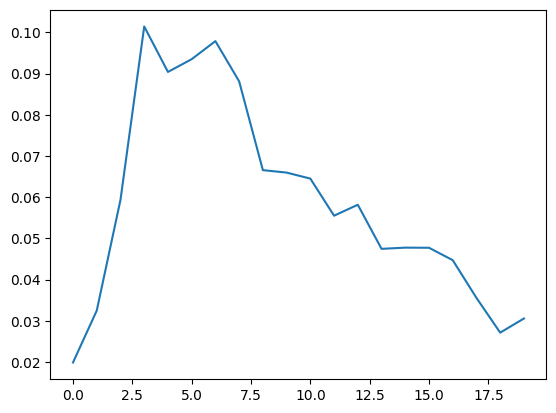

In [114]:
# test_history를 그래프로 시각화

plt.plot(test_history)
plt.show()

In [117]:
# 예측값 생성

model.eval()

preds, trues = [], []

with torch.no_grad():
    for x, y in test_dl:
        x = x.float()
        pred = model(x)
        preds.append(pred)
        trues.append(y)

# tensor 데이터들을 하나로 합쳐주고 차원을 벗겨낸 다음 array로 변환
preds = torch.cat(preds, dim=0).numpy()
trues = torch.cat(trues, dim=0).numpy()

# 스케일링 데이터를 원본 데이터로 변환
pred_origin = scaler_y.inverse_transform(preds).squeeze(-1)
true_origin = scaler_y.inverse_transform(trues).squeeze(-1)

In [118]:
split_idx = int(len(df) * train_ratio)
x_data = df['Date'].values[split_idx + window :]

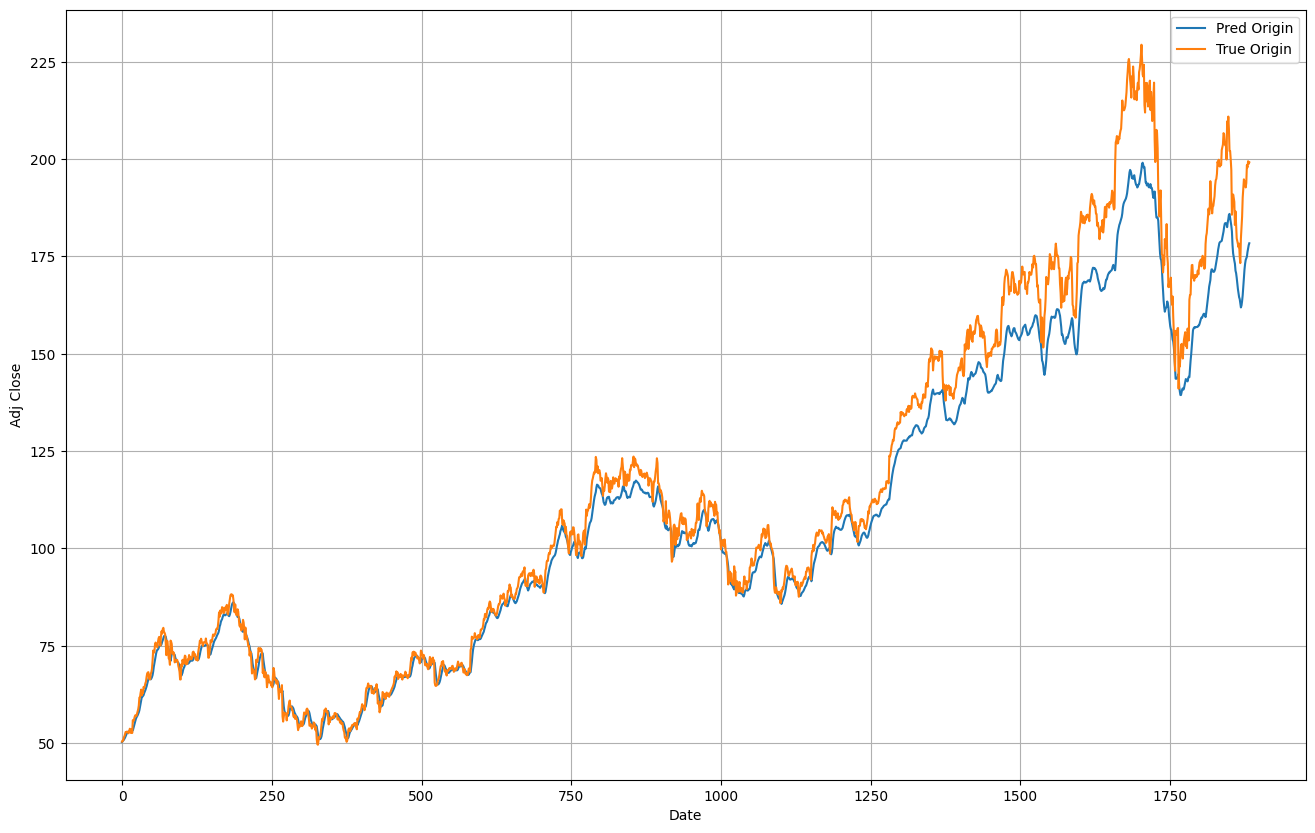

In [119]:
plt.figure(figsize = (16, 10))
plt.plot(pred_origin, label = 'Pred Origin')
plt.plot(true_origin, label = 'True Origin')

plt.legend()
plt.grid()
plt.xlabel('Date')
plt.ylabel('Adj Close')

plt.show()